# The Inverse: Undoing a Transformation

**This notebook is self-contained; it recaps the determinant briefly before using it.**

If a matrix moves space, its **inverse** is the matrix that moves it back. This notebook applies $A$ to a shape and then $A^{-1}$ to land exactly where it started, and then shows what goes wrong when the first transformation flattened space. That failure is precisely the case $\det A = 0$, which is why the determinant and the inverse belong in the same section.

## Learning objectives

- Define $A^{-1}$ by the property $A^{-1}A = AA^{-1} = I$.
- Explain why $\det A = 0$ means no inverse exists.
- Solve $A\mathbf{x} = \mathbf{b}$ as $\mathbf{x} = A^{-1}\mathbf{b}$ and compare with elimination.

## Background

The **identity matrix** $I = \begin{bmatrix}1&0\\0&1\end{bmatrix}$ leaves every vector alone: $I\mathbf{x} = \mathbf{x}$. The **inverse** of $A$, written $A^{-1}$, is the matrix that undoes it:

$$A^{-1}A = AA^{-1} = I.$$

For a $2\times2$ matrix there is a closed form:

$$A^{-1} = \frac{1}{ad - bc}\begin{bmatrix}d & -b\\ -c & a\end{bmatrix} = \frac{1}{\det A}\begin{bmatrix}d & -b\\ -c & a\end{bmatrix}.$$

Note where the **determinant** sits: in the denominator. If $\det A = 0$ the formula divides by zero and there is no inverse, the matrix is **singular**. Geometrically that makes sense: a transformation that flattened the plane onto a line threw information away, and nothing can bring it back.

## This notebook covers

1. Apply $A$, then $A^{-1}$, and land back on the original shape.
2. The $2\times2$ formula, and why the determinant in the denominator is the whole story.
3. Re-solving a system as $\mathbf{x} = A^{-1}\mathbf{b}$.
4. The singular case: what "no inverse" looks like.

**Prerequisites:** `U2-5_Determinants-1_AsArea`

**Dataset:** none, matrices are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)
# an "F" outline: deliberately asymmetric, so a reflection is impossible to miss
F = np.array([[0.0, 0.0], [0.0, 1.0], [0.6, 1.0], [0.6, 0.8], [0.2, 0.8],
              [0.2, 0.6], [0.5, 0.6], [0.5, 0.4], [0.2, 0.4], [0.2, 0.0],
              [0.0, 0.0]]).T          # 2 x n: each COLUMN is a point, so A @ F transforms them all

def draw_shape(ax, pts, color, label=None, alpha=1.0, lw=2):
    ax.plot(pts[0], pts[1], color=color, label=label, alpha=alpha, lw=lw)
    ax.fill(pts[0], pts[1], color=color, alpha=0.15 * alpha)

## 1. There and back again

Take a shape, apply $A$ to distort it, then apply $A^{-1}$ to the result. The three panels below show the round trip: the final shape is **identical** to the first, because $A^{-1}A = I$ leaves everything alone.

In [2]:
A = np.array([[2.0, 1.0],
              [0.5, 1.5]])
A_inv = np.linalg.inv(A)

helpers.show(A, name="A")
helpers.show(np.round(A_inv, 3), name="A^{-1}")
helpers.show(np.round(A_inv @ A, 10), name="A^{-1}A")     # rounded: floating point leaves crumbs

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

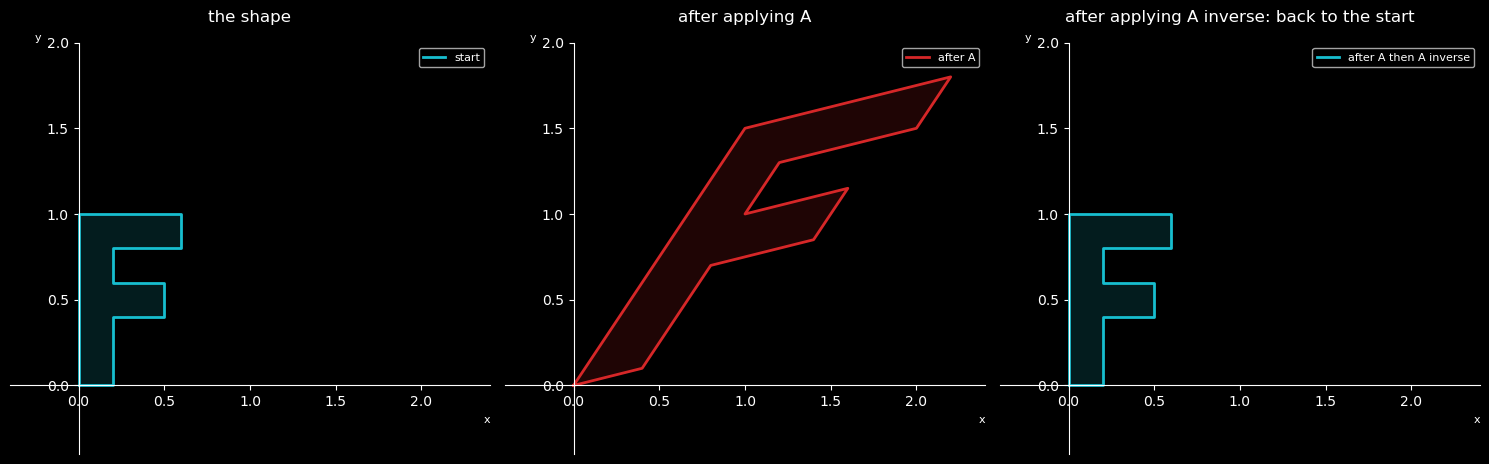

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

draw_shape(axes[0], F, "tab:cyan", "start")
axes[0].set_title("the shape", pad=15)

draw_shape(axes[1], A @ F, "tab:red", "after A")
axes[1].set_title("after applying A", pad=15)

draw_shape(axes[2], A_inv @ A @ F, "tab:cyan", "after A then A inverse")
axes[2].set_title("after applying A inverse: back to the start", pad=15)

for ax in axes:
    center_axes(ax); label_axes(ax)
    ax.set_xlim(-0.4, 2.4); ax.set_ylim(-0.4, 2.0); ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 2. The formula, and the determinant hiding in it

$$A^{-1} = \frac{1}{\det A}\begin{bmatrix}d & -b\\ -c & a\end{bmatrix}$$

Swap the diagonal entries, negate the off-diagonal ones, divide everything by the determinant. We build it by hand and check against `np.linalg.inv`.

The division is the important part. Every entry of $A^{-1}$ is scaled by $1/\det A$, so as $\det A$ shrinks toward zero the entries of the inverse blow up, and at exactly zero there is nothing to divide by. **A matrix is invertible if and only if $\det A \neq 0$.**

In [4]:
a, b = A[0]
c, d = A[1]
det = a * d - b * c

by_hand = (1 / det) * np.array([[d, -b],
                                [-c, a]])
helpers.show(np.round(by_hand, 3), label="by the formula")
helpers.show(np.round(A_inv, 3), label="from numpy")
print("same?", np.allclose(by_hand, A_inv))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

same? True


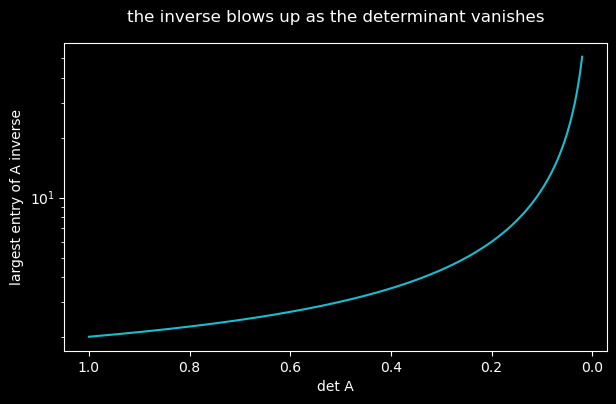

In [5]:
# as det -> 0, the inverse's entries blow up
scales = np.linspace(1.0, 0.02, 200)
biggest = []
for s in scales:
    M = np.array([[1.0, 1.0], [1.0, 1.0 + s]])     # det = s, shrinking toward 0
    biggest.append(np.abs(np.linalg.inv(M)).max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(scales, biggest, color="tab:cyan")
ax.set_xlabel("det A")
ax.set_ylabel("largest entry of A inverse")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_title("the inverse blows up as the determinant vanishes", pad=15)
plt.show()

## 3. Solving a system with the inverse

A system $A\mathbf{x} = \mathbf{b}$ can now be solved in one move. Multiply both sides on the left by $A^{-1}$:

$$A^{-1}A\mathbf{x} = A^{-1}\mathbf{b} \quad\Longrightarrow\quad I\mathbf{x} = A^{-1}\mathbf{b} \quad\Longrightarrow\quad \mathbf{x} = A^{-1}\mathbf{b}.$$

We re-solve the same system that was worked by hand with Gaussian elimination in §2.1, $x + y = 3,\; 2x + y = 5$, answer $(2, 1)$, and get the same answer.

A practical note: in real code, prefer `np.linalg.solve(A, b)` over `np.linalg.inv(A) @ b`. It is faster and numerically better behaved, computing the whole inverse just to multiply it by one vector does more work and loses more precision. The inverse is the right way to *think*; `solve` is the right way to *compute*.

In [6]:
A2 = np.array([[1.0, 1.0],
               [2.0, 1.0]])
b2 = np.array([3.0, 5.0])

helpers.show_aug(A2, b2, name="[A | b]")
helpers.show(np.linalg.inv(A2) @ b2, label="x = A inverse times b")
helpers.show(np.linalg.solve(A2, b2), label="np.linalg.solve(A, b)")
print("matches the (2, 1) found by elimination in section 2.1")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

matches the (2, 1) found by elimination in section 2.1


## 4. When there is no inverse

Take $B = \begin{bmatrix}1 & 2\\ 2 & 4\end{bmatrix}$, whose second column is exactly twice the first. Its determinant is $1\cdot4 - 2\cdot2 = 0$, so by the previous notebook it flattens the plane onto a line.

Nothing can undo that. Two different starting points can land on the same place after flattening, so there is no rule that sends each result back where it came from, an inverse would have to choose, and it cannot. NumPy refuses.

In [7]:
B = np.array([[1.0, 2.0],
              [2.0, 4.0]])
helpers.show(B, name="B")
print(f"det(B) = {np.linalg.det(B):.1f}")

# two clearly different points that B sends to exactly the same place
p = np.array([2.0, 0.0])
q = np.array([0.0, 1.0])
helpers.show(B @ p, label="B times [2, 0]")
helpers.show(B @ q, label="B times [0, 1]")
print("same image from different inputs -> nothing could undo B\n")

try:
    np.linalg.inv(B)
except np.linalg.LinAlgError as e:
    print("np.linalg.inv(B) raises LinAlgError:", e)

<IPython.core.display.Math object>

det(B) = 0.0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

same image from different inputs -> nothing could undo B

np.linalg.inv(B) raises LinAlgError: Singular matrix


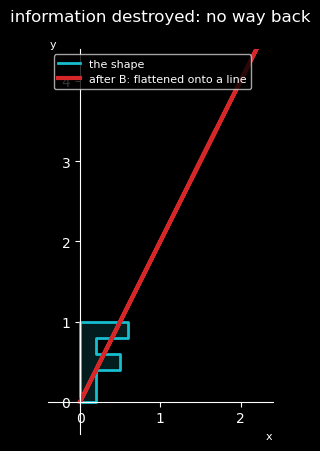

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5))
draw_shape(ax, F, "tab:cyan", "the shape")
flat = B @ F
ax.plot(flat[0], flat[1], color="tab:red", lw=3, label="after B: flattened onto a line")

center_axes(ax); label_axes(ax)
ax.set_xlim(-0.4, 2.4); ax.set_ylim(-0.4, 4.4); ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("information destroyed: no way back", pad=20)
plt.show()

## 5. Summary

- $A^{-1}$ is the transformation that **undoes** $A$: $A^{-1}A = AA^{-1} = I$.
- For a $2\times2$, $A^{-1} = \frac{1}{\det A}\begin{bmatrix}d&-b\\-c&a\end{bmatrix}$, the determinant sits in the **denominator**, so $\det A = 0$ means no inverse.
- $A\mathbf{x} = \mathbf{b}$ solves as $\mathbf{x} = A^{-1}\mathbf{b}$; in code prefer `np.linalg.solve`.
- A **singular** matrix flattens space and destroys information, so no inverse can exist.

Next: what to do when a system has *no* solution at all, the pseudo-inverse and least squares (`U2-5_Determinants-3_PseudoInverseAndLeastSquares`).